# HW14 — эмбеддинги, FAISS, оценка retrieval и mini-RAG

В этой работе:
- выбрана компактная база знаний по правилам и инженерным практикам курса;
- используется фиксированный чанкинг;
- векторизация выполняется через TF-IDF;
- строится `FAISS`-индекс для поиска по чанкам;
- считается retrieval-качество по контрольным запросам;
- выполняется обновление базы знаний и сравнение до/после;
- собирается простой mini-RAG с ответом и источниками.


In [1]:

import os
import random
import json
import subprocess
import sys
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ARTIFACTS_DIR = Path("./artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

try:
    import faiss
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "faiss-cpu"])
    import faiss

print("faiss version:", getattr(faiss, "__version__", "installed"))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 13.2 MB/s eta 0:00:00 0:00:01



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: /Users/vladimirfilimonov/PycharmProjects/Artificial_Intelligence_Engineering_2025-26/.venv/bin/python -m pip install --upgrade pip


faiss version: 1.13.2


In [2]:

base_docs = pd.read_csv("./knowledge_base/knowledge_base_base.csv")
update_docs = pd.read_csv("./knowledge_base/knowledge_base_update.csv")

print("Number of base documents:", len(base_docs))
display(base_docs[["source", "title"]].head())

print("\nExample documents:")
display(base_docs[["source", "text"]].head(3))


Number of base documents: 12


,source,title
0,doc_01_course_structure,Course Structure and Weekly Workflow
1,doc_02_submission_rules,Submission Rules
2,doc_03_validation_policy,Validation and Test Policy
3,doc_04_retrieval_basics,Retrieval Basics
4,doc_05_chunking_guidelines,Chunking Guidelines



Example documents:


,source,text
0,doc_01_course_structure,The AI Engineering course is organized around ...
1,doc_02_submission_rules,A homework submission is considered complete o...
2,doc_03_validation_policy,Validation data is used to select a model or c...


Предметная область — учебные правила и инженерные практики курса по ИИ. Такая база знаний удобна для retrieval, потому что документы тематически связаны, содержат короткие, но информативные утверждения и по ним легко сформулировать контрольные вопросы для mini-RAG.

In [3]:

def sentence_split(text: str):
    parts = re.split(r'(?<=[.!?])\s+', re.sub(r"\s+", " ", text.strip()))
    return [p.strip() for p in parts if p.strip()]

def chunk_document(text: str, chunk_size: int = 220, overlap_sentences: int = 1):
    sentences = sentence_split(text)
    chunks = []
    i = 0
    while i < len(sentences):
        current = []
        current_len = 0
        start_i = i
        while i < len(sentences):
            sent = sentences[i]
            add_len = len(sent) + (1 if current else 0)
            if current and current_len + add_len > chunk_size:
                break
            current.append(sent)
            current_len += add_len
            i += 1
        if not current:
            current = [sentences[i]]
            i += 1
        chunks.append(" ".join(current))
        if i >= len(sentences):
            break
        i = max(i - overlap_sentences, start_i + 1)
    return chunks

def build_chunks(documents_df, chunk_size=220, overlap_sentences=1):
    rows = []
    for _, doc in documents_df.iterrows():
        chunks = chunk_document(doc["text"], chunk_size=chunk_size, overlap_sentences=overlap_sentences)
        for j, ch in enumerate(chunks, start=1):
            rows.append({
                "chunk_id": f'{doc["source"]}_chunk_{j:02d}',
                "source": doc["source"],
                "title": doc["title"],
                "text": ch
            })
    return pd.DataFrame(rows)

chunks_df = build_chunks(base_docs, chunk_size=220, overlap_sentences=1)
print("Number of chunks:", len(chunks_df))
display(chunks_df.head(8))


Number of chunks: 38


,chunk_id,source,title,text
0,doc_01_course_structure_chunk_01,doc_01_course_structure,Course Structure and Weekly Workflow,The AI Engineering course is organized around ...
1,doc_01_course_structure_chunk_02,doc_01_course_structure,Course Structure and Weekly Workflow,Each seminar introduces one engineering topic ...
2,doc_01_course_structure_chunk_03,doc_01_course_structure,Course Structure and Weekly Workflow,Every homework should be placed in homeworks/H...
3,doc_01_course_structure_chunk_04,doc_01_course_structure,Course Structure and Weekly Workflow,The recommended workflow is to study the theor...
4,doc_02_submission_rules_chunk_01,doc_02_submission_rules,Submission Rules,A homework submission is considered complete o...
5,doc_02_submission_rules_chunk_02,doc_02_submission_rules,Submission Rules,The notebook must run from top to bottom witho...
6,doc_02_submission_rules_chunk_03,doc_02_submission_rules,Submission Rules,Reports should not rename sections from the pr...
7,doc_03_validation_policy_chunk_01,doc_03_validation_policy,Validation and Test Policy,Validation data is used to select a model or c...


In [4]:

def build_faiss_index(texts):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words="english")
    X = vectorizer.fit_transform(texts).astype(np.float32)
    X = normalize(X, norm="l2")
    dense = X.toarray().astype("float32")
    index = faiss.IndexFlatIP(dense.shape[1])
    index.add(dense)
    return vectorizer, dense, index

def search(query, vectorizer, index, chunks_df, top_k=3):
    q = vectorizer.transform([query]).astype(np.float32)
    q = normalize(q, norm="l2")
    q_dense = q.toarray().astype("float32")
    scores, idx = index.search(q_dense, top_k)
    result = chunks_df.iloc[idx[0]].copy()
    result["score"] = scores[0]
    return result

vectorizer, chunk_vectors, index = build_faiss_index(chunks_df["text"].tolist())

demo_queries = [
    "What does hit at k measure?",
    "Why is chunking important?",
    "How should validation and test be used?"
]
for q in demo_queries:
    print("\nQUERY:", q)
    display(search(q, vectorizer, index, chunks_df, top_k=3)[["source", "chunk_id", "score", "text"]])



QUERY: What does hit at k measure?


,source,chunk_id,score,text
35,doc_12_practical_limits,doc_12_practical_limits_chunk_01,0.149227,A compact educational retrieval project does n...
20,doc_07_retrieval_metrics,doc_07_retrieval_metrics_chunk_02,0.133590,Hit@k answers whether at least one relevant so...
19,doc_07_retrieval_metrics,doc_07_retrieval_metrics_chunk_01,0.115545,A minimal retrieval benchmark can be built fro...



QUERY: Why is chunking important?


,source,chunk_id,score,text
14,doc_05_chunking_guidelines,doc_05_chunking_guidelines_chunk_02,0.154649,"If chunks are too large, retrieval may bring t..."
15,doc_05_chunking_guidelines,doc_05_chunking_guidelines_chunk_03,0.117151,"If chunks are too small, the answer may be fra..."
13,doc_05_chunking_guidelines,doc_05_chunking_guidelines_chunk_01,0.111657,Chunking splits documents into smaller fragmen...



QUERY: How should validation and test be used?


,source,chunk_id,score,text
7,doc_03_validation_policy,doc_03_validation_policy_chunk_01,0.333237,Validation data is used to select a model or c...
8,doc_03_validation_policy,doc_03_validation_policy_chunk_02,0.240730,A common mistake is to repeatedly inspect test...
9,doc_03_validation_policy,doc_03_validation_policy_chunk_03,0.156518,"The correct pattern is train on train, choose ..."


In [5]:

control_queries = [
    ("What files must be included in a homework folder?", "doc_02_submission_rules"),
    ("How should validation and test be used during experiments?", "doc_03_validation_policy"),
    ("Why is chunking important for retrieval quality?", "doc_05_chunking_guidelines"),
    ("What does hit@k measure?", "doc_07_retrieval_metrics"),
    ("Why should vectors be normalized for cosine similarity in FAISS?", "doc_06_faiss_notes"),
    ("What is mini-RAG in this course context?", "doc_09_mini_rag"),
    ("Why can a report get comments even if the notebook works?", "doc_11_reports_and_artifacts"),
    ("Why is a simple pipeline acceptable for an educational retrieval project?", "doc_12_practical_limits"),
    ("How do you compare retrieval before and after updating the knowledge base?", "doc_08_knowledge_base_updates"),
    ("What should error analysis explain in a retrieval homework?", "doc_10_error_analysis"),
]

def evaluate_queries(chunks_df, vectorizer, index, queries, top_k=3):
    rows = []
    for query, expected_source in queries:
        res = search(query, vectorizer, index, chunks_df, top_k=top_k)
        retrieved_sources = res["source"].tolist()
        hit = int(expected_source in retrieved_sources)
        ranks = [i + 1 for i, src in enumerate(retrieved_sources) if src == expected_source]
        rows.append({
            "query": query,
            "expected_source": expected_source,
            "retrieved_sources": "; ".join(retrieved_sources),
            "hit_at_k": hit,
            "recall_at_k": 1.0 if hit else 0.0,
            "rank_of_first_relevant": ranks[0] if ranks else None,
        })
    return pd.DataFrame(rows)

retrieval_eval = evaluate_queries(chunks_df, vectorizer, index, control_queries, top_k=3)
retrieval_eval.to_csv(ARTIFACTS_DIR / "retrieval_eval.csv", index=False)

hit_at_k = retrieval_eval["hit_at_k"].mean()
recall_at_k = retrieval_eval["recall_at_k"].mean()
mrr_at_k = retrieval_eval["rank_of_first_relevant"].dropna().apply(lambda r: 1 / r).mean()

print("hit@3 =", round(hit_at_k, 4))
print("recall@3 =", round(recall_at_k, 4))
print("MRR@3 =", round(mrr_at_k, 4))
display(retrieval_eval)


hit@3 = 1.0
recall@3 = 1.0
MRR@3 = 0.8333


,query,expected_source,retrieved_sources,hit_at_k,recall_at_k,rank_of_first_relevant
0,What files must be included in a homework folder?,doc_02_submission_rules,doc_01_course_structure; doc_02_submission_rul...,1,1.0,2
1,How should validation and test be used during ...,doc_03_validation_policy,doc_03_validation_policy; doc_03_validation_po...,1,1.0,1
2,Why is chunking important for retrieval quality?,doc_05_chunking_guidelines,doc_08_knowledge_base_updates; doc_04_retrieva...,1,1.0,3
3,What does hit@k measure?,doc_07_retrieval_metrics,doc_12_practical_limits; doc_07_retrieval_metr...,1,1.0,2
4,Why should vectors be normalized for cosine si...,doc_06_faiss_notes,doc_06_faiss_notes; doc_06_faiss_notes; doc_06...,1,1.0,1
5,What is mini-RAG in this course context?,doc_09_mini_rag,doc_09_mini_rag; doc_01_course_structure; doc_...,1,1.0,1
6,Why can a report get comments even if the note...,doc_11_reports_and_artifacts,doc_11_reports_and_artifacts; doc_01_course_st...,1,1.0,1
7,Why is a simple pipeline acceptable for an edu...,doc_12_practical_limits,doc_12_practical_limits; doc_09_mini_rag; doc_...,1,1.0,1
8,How do you compare retrieval before and after ...,doc_08_knowledge_base_updates,doc_08_knowledge_base_updates; doc_08_knowledg...,1,1.0,1
9,What should error analysis explain in a retrie...,doc_10_error_analysis,doc_10_error_analysis; doc_10_error_analysis; ...,1,1.0,1


,setting,hit_at_k,recall_at_k,mrr_at_k
0,top_k=2,0.9,0.9,0.888889
1,top_k=3,1.0,1.0,0.833333


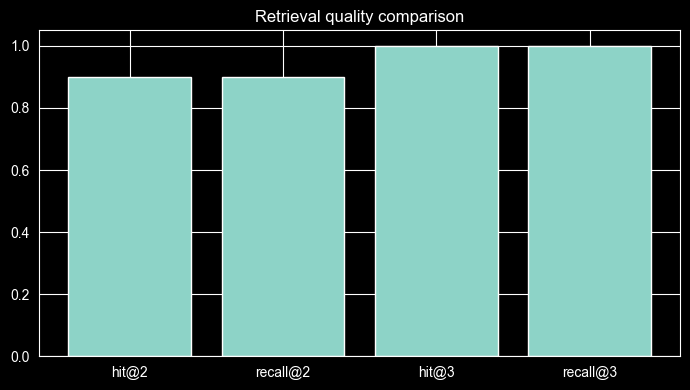

In [6]:

eval_top2 = evaluate_queries(chunks_df, vectorizer, index, control_queries, top_k=2)
eval_top3 = evaluate_queries(chunks_df, vectorizer, index, control_queries, top_k=3)

experiment_df = pd.DataFrame({
    "setting": ["top_k=2", "top_k=3"],
    "hit_at_k": [eval_top2["hit_at_k"].mean(), eval_top3["hit_at_k"].mean()],
    "recall_at_k": [eval_top2["recall_at_k"].mean(), eval_top3["recall_at_k"].mean()],
    "mrr_at_k": [
        eval_top2["rank_of_first_relevant"].dropna().apply(lambda r: 1 / r).mean(),
        eval_top3["rank_of_first_relevant"].dropna().apply(lambda r: 1 / r).mean(),
    ]
})
display(experiment_df)

plt.figure(figsize=(7, 4))
plt.bar(["hit@2", "recall@2", "hit@3", "recall@3"], [
    experiment_df.iloc[0]["hit_at_k"],
    experiment_df.iloc[0]["recall_at_k"],
    experiment_df.iloc[1]["hit_at_k"],
    experiment_df.iloc[1]["recall_at_k"],
])
plt.ylim(0, 1.05)
plt.title("Retrieval quality comparison")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "retrieval_quality_plot.png", dpi=160)
plt.show()


In [7]:

updated_docs = pd.concat([base_docs, update_docs], ignore_index=True)
chunks_after = build_chunks(updated_docs, chunk_size=220, overlap_sentences=1)
vectorizer_after, chunk_vectors_after, index_after = build_faiss_index(chunks_after["text"].tolist())

update_queries = [
    ("When is the GPU lab open?", "upd_01_gpu_lab_policy"),
    ("What is the late submission window?", "upd_02_late_submission_policy"),
    ("Which files are required specifically for HW14?", "upd_03_hw14_specific_note"),
    ("How do students reserve a GPU lab slot?", "upd_01_gpu_lab_policy"),
]

before = evaluate_queries(chunks_df, vectorizer, index, update_queries, top_k=3)
after = evaluate_queries(chunks_after, vectorizer_after, index_after, update_queries, top_k=3)

before_after_rows = []
for i in range(len(update_queries)):
    before_after_rows.append({
        "query": update_queries[i][0],
        "before_retrieved_sources": before.iloc[i]["retrieved_sources"],
        "after_retrieved_sources": after.iloc[i]["retrieved_sources"],
        "changed": int(before.iloc[i]["retrieved_sources"] != after.iloc[i]["retrieved_sources"]),
    })
before_after_df = pd.DataFrame(before_after_rows)
before_after_df.to_csv(ARTIFACTS_DIR / "retrieval_before_after_update.csv", index=False)
display(before_after_df)


,query,before_retrieved_sources,after_retrieved_sources,changed
0,When is the GPU lab open?,doc_01_course_structure; doc_01_course_structu...,upd_01_gpu_lab_policy; doc_01_course_structure...,1
1,What is the late submission window?,doc_02_submission_rules; doc_01_course_structu...,upd_02_late_submission_policy; upd_02_late_sub...,1
2,Which files are required specifically for HW14?,doc_11_reports_and_artifacts; doc_02_submissio...,upd_03_hw14_specific_note; doc_02_submission_r...,1
3,How do students reserve a GPU lab slot?,doc_01_course_structure; doc_01_course_structu...,upd_01_gpu_lab_policy; upd_01_gpu_lab_policy; ...,1


In [8]:

def mini_rag_answer(question, chunks_df, vectorizer, index, top_k=3):
    retrieved = search(question, vectorizer, index, chunks_df, top_k=top_k)
    context = " ".join(retrieved["text"].tolist())
    sentences = sentence_split(context)
    q_terms = set(re.findall(r"[a-zA-Z]{3,}", question.lower()))
    scored = []
    for sent in sentences:
        terms = set(re.findall(r"[a-zA-Z]{3,}", sent.lower()))
        overlap = len(q_terms & terms)
        scored.append((overlap, sent))
    scored.sort(key=lambda x: x[0], reverse=True)
    best = [s for score, s in scored[:2] if s]
    if not best:
        best = sentences[:2]
    answer = " ".join(best)
    sources = "; ".join(retrieved["source"].tolist())
    return answer, sources

rag_questions = [
    "How should a student use validation and test splits correctly?",
    "What does hit@k mean in retrieval evaluation?",
    "Why can chunk size harm retrieval quality?",
    "What is the purpose of updating a knowledge base?",
    "What files are required specifically for HW14 after the update?",
]

rag_rows = []
for q in rag_questions:
    ans, src = mini_rag_answer(q, chunks_after, vectorizer_after, index_after, top_k=3)
    rag_rows.append({"question": q, "answer": ans, "retrieved_sources": src})

rag_examples = pd.DataFrame(rag_rows)
rag_examples.to_csv(ARTIFACTS_DIR / "rag_examples.csv", index=False)
display(rag_examples)


,question,answer,retrieved_sources
0,How should a student use validation and test s...,"The correct pattern is train on train, choose ...",doc_03_validation_policy; doc_03_validation_po...
1,What does hit@k mean in retrieval evaluation?,"The notebook should demonstrate chunking, vect...",upd_03_hw14_specific_note; doc_12_practical_li...
2,Why can chunk size harm retrieval quality?,"After an update, retrieval quality can change ...",doc_08_knowledge_base_updates; doc_06_faiss_no...
3,What is the purpose of updating a knowledge base?,Updating a knowledge base means adding new doc...,doc_08_knowledge_base_updates; doc_11_reports_...
4,What files are required specifically for HW14 ...,For HW14 the required artifacts are retrieval_...,upd_03_hw14_specific_note; doc_02_submission_r...


### Краткий анализ ошибок

Пограничные случаи обычно возникают по трём причинам. 
Во-первых, запрос может использовать лексику, которая слабо пересекается с формулировкой в документе, и тогда retrieval поднимает менее точный чанк. 
Во-вторых, слишком общий вопрос приводит к смешанному контексту из нескольких чанков. 
В-третьих, если нужный документ появился только после обновления базы знаний, то до переиндексации система просто не имела правильного источника. 
Это показывает, что качество ответа mini-RAG напрямую зависит от качества retrieval и от полноты базы знаний.
